In [ ]:
!pip install -q evaluate

In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git

In [3]:
import os
from pathlib import Path
import random
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import ConvNextImageProcessor, ConvNextForImageClassification, TrainingArguments,Trainer, AutoModel, AutoProcessor,DefaultDataCollator
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from datasets import load_dataset, Image, Dataset
from tqdm import tqdm
import glob
import xml.etree.ElementTree as ET
import json

# Часть 1

## 1.1 Transfer Learning

In [ ]:
train_ds = load_dataset("imagefolder", data_dir='/kaggle/input/hw2-dataset/HW2_dataset/train_dataset',)
test_ds = load_dataset("imagefolder", data_dir='/kaggle/input/hw2-dataset/HW2_dataset/test_dataset',)

def extract_label(path):
  filename = os.path.basename(path)
  tokens = filename.split('.')[0].split('_')[:-1]
  if len(tokens) >= 2:
    label = "_".join(tokens)
  else:
    label = "_".join(tokens)
  return label

paths = [img.filename for img in test_ds['train']['image']]
labels = [extract_label(p) for p in paths]

id2label = train_ds['train'].features['label'].names
label2id = {name: i for i, name in enumerate(id2label)}

test_labels = [label2id[l] for l in labels]

test_ds = Dataset.from_dict({
    "image": paths,
    "label": test_labels,
    })

test_ds = test_ds.cast_column("image", Image())

In [ ]:
processor = ConvNextImageProcessor.from_pretrained("facebook/convnext-tiny-224")
model = ConvNextForImageClassification.from_pretrained(
    "facebook/convnext-tiny-224",
    num_labels=len(labels),
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)},
    ignore_mismatched_sizes=True
)

In [7]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images=images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

In [8]:
train_ds['train'] = train_ds['train'].with_transform(preprocess)
test_ds = test_ds.with_transform(preprocess)

In [9]:
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

In [10]:
for name, param in model.named_parameters():
  if "classifier" not in name:
    param.requires_grad = False

In [11]:
accuracy_metric = evaluate.load("accuracy")

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

In [13]:
epochs = 6
lr = 1e-4
weght_decay = 0.01
batch_size = 32

In [ ]:
training_args = TrainingArguments(
    output_dir='output',
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    save_strategy="epoch",
    weight_decay=weght_decay,
    learning_rate=lr,
    logging_dir="output/logs",
    report_to='tensorboard',
    remove_unused_columns=False,
    push_to_hub=False,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds['train'],
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

In [16]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
500,3.890670
1000,2.522819
1500,2.309148


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=1836, training_loss=2.7863098011557055, metrics={'train_runtime': 1186.9686, 'train_samples_per_second': 98.813, 'train_steps_per_second': 1.547, 'total_flos': 3.027653688859656e+18, 'train_loss': 2.7863098011557055, 'epoch': 6.0})

In [17]:
test_metrics = trainer.evaluate(test_ds)
print(test_metrics["eval_accuracy"])

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


0.3747474747474748


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


NameError: name 'model_str' is not defined

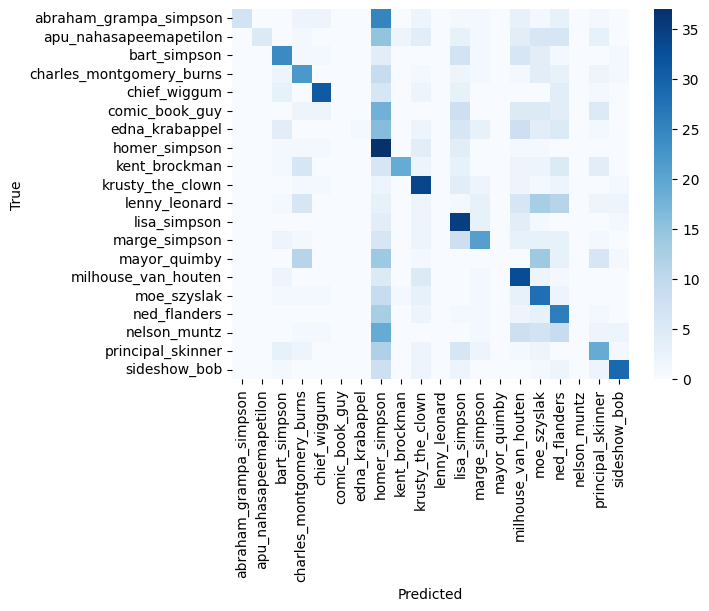

In [ ]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=id2label, yticklabels=id2label)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
    
plt.hist(conf.cpu(), bins=20)
plt.tight_layout()
plt.show()

Модель была выбрана из-за небольшого размера и низких затрат на обучение. Качество классификации значительно ниже, чем в hw2. Некоторые классы не были предсказаны

## 1.2 Zero-shot classification

In [ ]:
clip_model = AutoModel.from_pretrained("openai/clip-vit-large-patch14").to("cuda")
clip_processor = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")

siglip_model = AutoModel.from_pretrained("google/siglip2-base-patch16-224").to("cuda")
siglip_processor = AutoProcessor.from_pretrained("google/siglip2-base-patch16-224")

metaclip_model = AutoModel.from_pretrained("facebook/metaclip-2-worldwide-s16", torch_dtype=torch.bfloat16, attn_implementation="sdpa").to("cuda")
metaclip_processor = AutoProcessor.from_pretrained("facebook/metaclip-2-worldwide-s16")

In [22]:
models = [(clip_model, clip_processor),(siglip_model, siglip_processor),(metaclip_model, metaclip_processor)]

In [23]:
def collate_pil(batch):
    return {
        "image": [item["image"] for item in batch],
        "label": [item["label"] for item in batch],
    }


Model openai/clip-vit-large-patch14


100%|██████████| 62/62 [01:02<00:00,  1.00s/it]


Accuracy: 0.6636


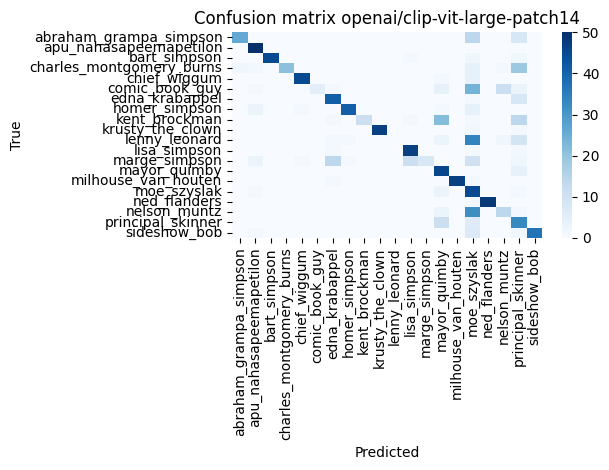

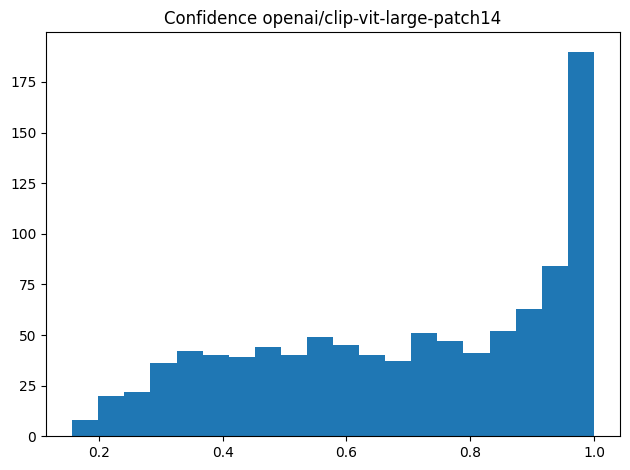


Model google/siglip2-base-patch16-224


100%|██████████| 62/62 [00:16<00:00,  3.84it/s]


Accuracy: 0.4131


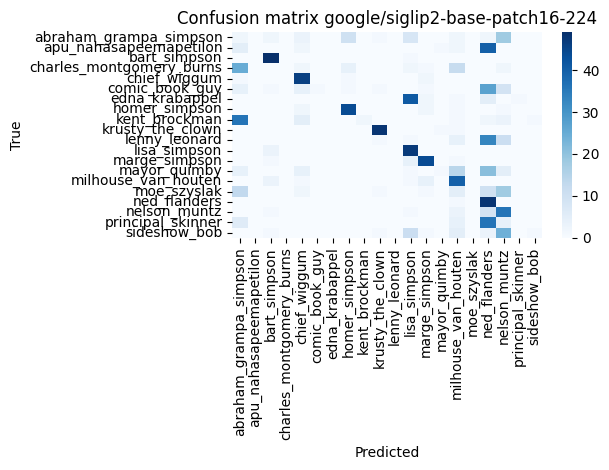

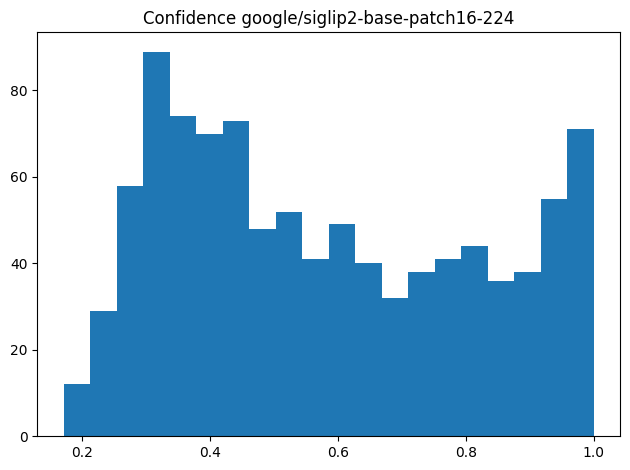


Model facebook/metaclip-2-worldwide-s16


100%|██████████| 62/62 [00:09<00:00,  6.31it/s]


Accuracy: 0.1879


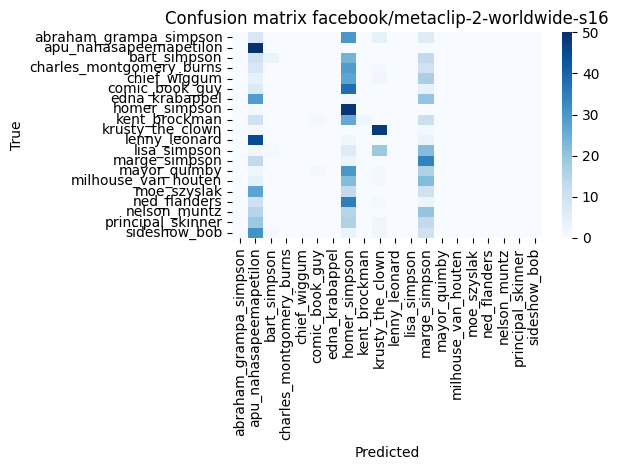

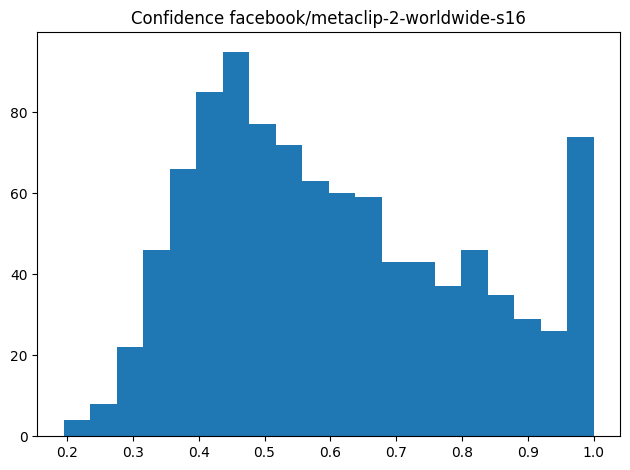

In [25]:
for model, processor in models:
    model_str = model.config._name_or_path
    print(f"\nModel {model_str}")
    outputs = torch.empty(0).to('cuda')
    dl = DataLoader(test_ds, shuffle=False, batch_size=16, collate_fn=collate_pil)
    for batch in tqdm(dl):
        inputs = processor(images=batch["image"], text=id2label, return_tensors="pt", padding='max_length').to("cuda")
        with torch.no_grad():
            batch_outputs = model(**inputs)
            outputs = torch.cat((outputs, batch_outputs.logits_per_image), dim=0)
            
    probs = outputs.softmax(dim=-1)
    preds = probs.argmax(dim=-1)
    conf = probs[torch.tensor(range(len(preds))), preds]
    
    gt = torch.tensor(test_ds["label"])
    
    acc = accuracy_score(gt, preds.cpu())
    print(f"Accuracy: {acc:.4f}")
    
    cm = confusion_matrix(gt, preds.cpu())
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=id2label, yticklabels=id2label)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix {model_str}")
    plt.tight_layout()
    plt.show()
    
    plt.hist(conf.cpu(), bins=20)
    plt.title(f"Confidence {model_str}")
    plt.tight_layout()
    plt.show()

openai/clip-vit-large-patch14 справляется лучше других двух моделей. moe_szyslak и nelson_muntz часто оказываются предсказаны вместо верных классов. Модель довольно часто уверена в своих предсказаниях.

google/siglip2-base-patch16-224 часто вместо lisa_simpson выдает edna_krabappel, некоторые классы не предсказаны вообще. Модель горазно меньше уверена в своих предсказаниях

facebook/metaclip-2-worldwide-s16 по сути предсказывает только 4 класса, из-за чего качество очень низкое.

## 1.3 Vision-Language Model

In [5]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-2B-Instruct", dtype="auto", device_map="auto")
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-2B-Instruct")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [27]:
prompt = ("Я покажу тебе изображение.\n"
            f"Твоя задача — выбрать ровно одного персонажа из списка, который изображен на фото:{id2label}\n"
            "Ответ должен содержать только имя персонажа, без объяснений.")

In [25]:
def extract_label(text, class_names):
    text = text.lower()
    text = text.split("assistant")[-1]
    for cls in class_names:
        if cls.lower() in text:
            return text, label2id[cls]
    return text, -1

  0%|          | 0/990 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/generation/utils.py:2652: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
100%|██████████| 990/990 [56:58<00:00,  3.45s/it]  


Accuracy: 0.3152


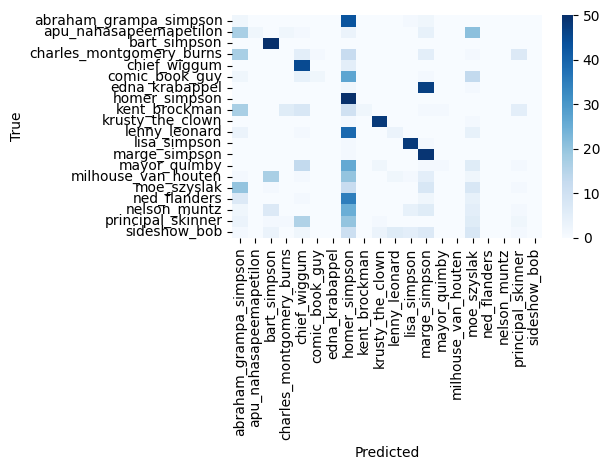

In [29]:
preds = []
gts = []
label_preds = []
for item in tqdm(test_ds):
    img = item["image"]
    gt = item["label"]
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": img
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]
    inputs = qwen_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    output = qwen_model.generate(**inputs)
    responce = qwen_processor.batch_decode(output,skip_special_tokens=True)[0]
    label_pred, pred = extract_label(responce,id2label)
    
    preds.append(pred)
    label_preds.append(label_pred)
    gts.append(gt)
acc = accuracy_score(gts, preds)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(gts, preds)
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=id2label, yticklabels=id2label)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [26]:
prompt = ("Which character from The Simpsons cartoon series is depicted in the photo?\n"
        "The answer should contain only the name of the character, without explanations, strictly in the format specified in the example.\n"
          "Examples: homer_simpson, abraham_grampa_simpson, moe_szyslak, sideshow_bob, krusty_the_clown")

  0%|          | 0/990 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/generation/utils.py:2652: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
100%|██████████| 990/990 [47:10<00:00,  2.86s/it]


Accuracy: 0.2222


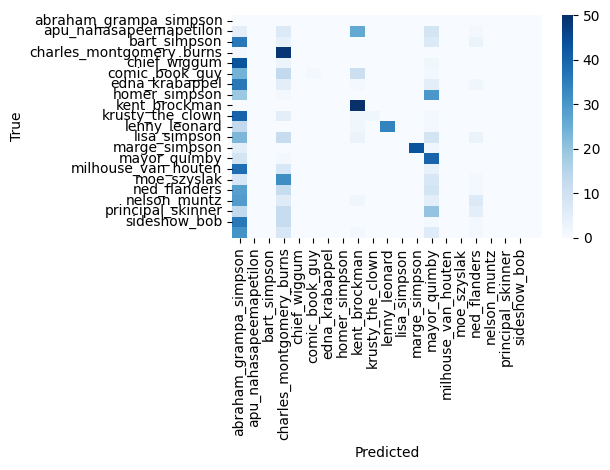

In [27]:
preds_ = []
gts_ = []
label_preds = []
for item in tqdm(test_ds):
    img = item["image"]
    gt = item["label"]
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": img
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]
    inputs = qwen_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    output = qwen_model.generate(**inputs)
    responce = qwen_processor.batch_decode(output,skip_special_tokens=True)[0]
    label_pred, pred = extract_label(responce,id2label)
    
    preds_.append(pred)
    label_preds.append(label_pred)
    gts_.append(gt)
acc = accuracy_score(gts_, preds_)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(gts_, preds_)
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=id2label, yticklabels=id2label)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Модель узнает популярных персонажей и плохо справляется с менее известными. Accuracy ниже по сравнению с моделями, специализирующимися на классификации изображений. Более четкий и жесткий промпт с конкретным списком классов позволяет добиться большей точности.

# Часть 2

## 2.1 Zero-shot object detection

In [28]:
from PIL import Image, ImageDraw, ImageFont

data_dir = "/kaggle/input/intersection-flow-5k/Intersection-Flow-5K"
with open(f'{data_dir}/classes.txt') as f:
    classes = [line.strip() for line in f.readlines()]
val_img = list(Path(f"{data_dir}/images/val").glob("*.jpg"))

In [ ]:
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor

dino_processor = AutoProcessor.from_pretrained("openmmlab-community/mm_grounding_dino_large_all")
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained("openmmlab-community/mm_grounding_dino_large_all").to("cuda")

In [30]:
 def visualize_prediction(results, model_name, sample_idx=0):
    pred = results["predictions"][sample_idx]
    image = Image.open(pred["image"])
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default(size=30)
    
    detections = pred["detections"]
    
    for box, score, label in zip(detections["boxes"], detections["scores"], detections["labels"]):
        xmin,ymin,xmax,ymax = box
        draw.rectangle([xmin,ymin,xmax,ymax], outline="red", width=3)
        draw.text((xmin, ymin-8), f'{label} {score:.2f}', font=font)
    
    title = f'{model_name}\n' 
    plt.figure(figsize=(20,12))
    plt.title(title)
    plt.axis('off')
    plt.imshow(image)
    plt.show()

  0%|          | 0/722 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:92: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)
100%|██████████| 722/722 [32:03<00:00,  2.66s/it]


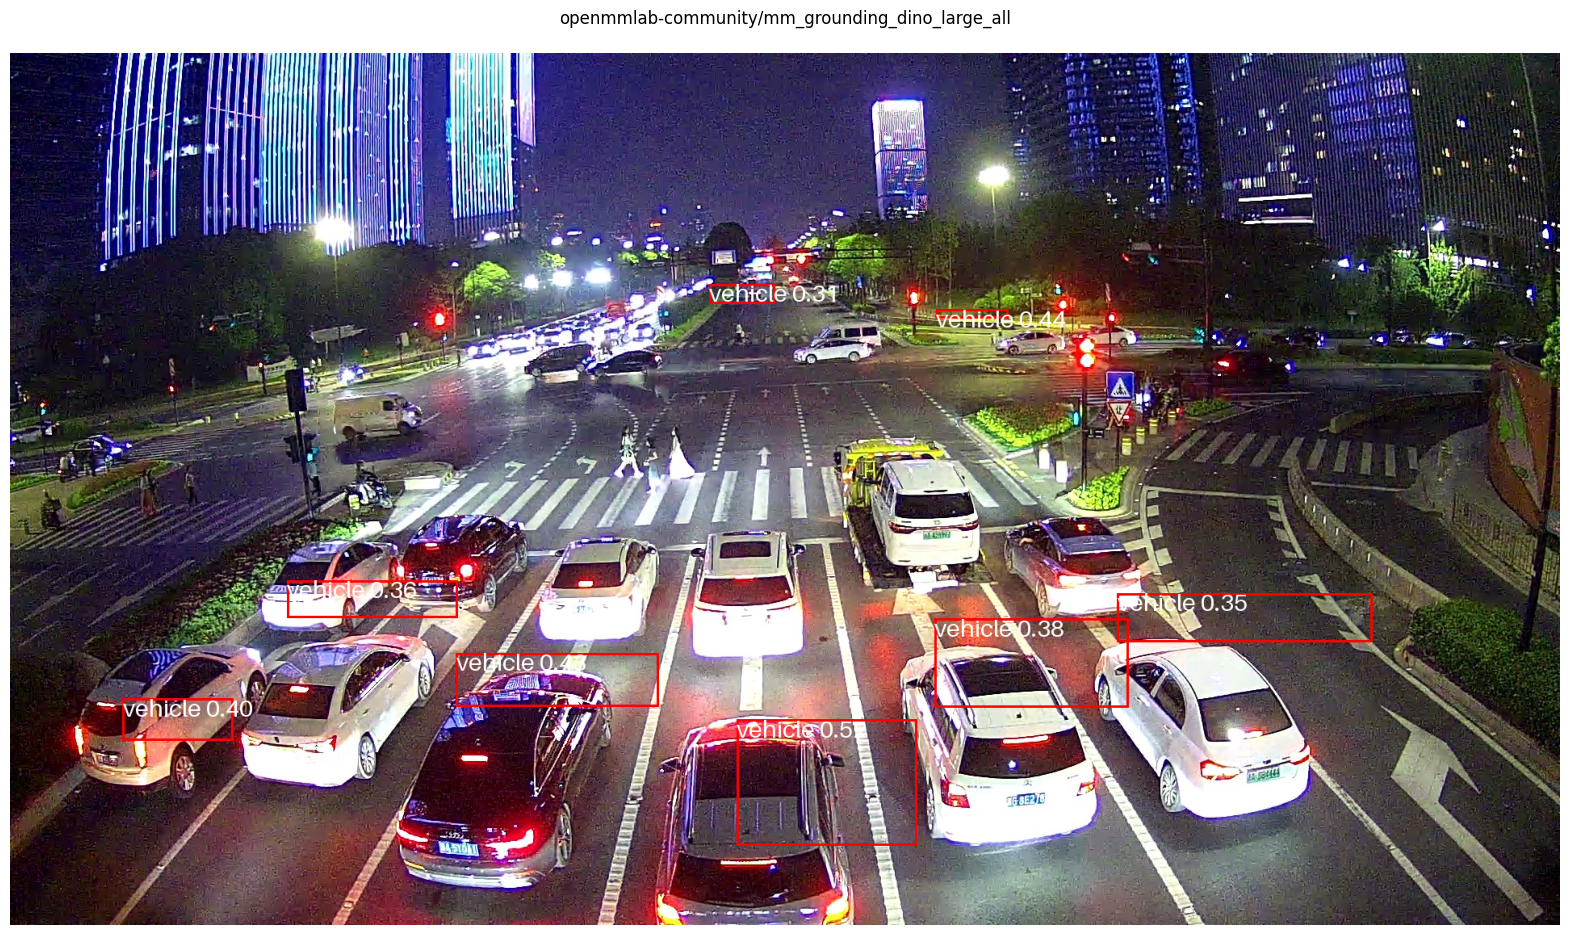

In [31]:
threshold=0.3
dino_results = {'confidences': [],
            'num_detections': [],
            'class_distribution': {},
            'predictions': []
        }
for img_path in tqdm(val_img):
    image = Image.open(img_path).convert("RGB")
    inputs = dino_processor(images=image, text=[classes], return_tensors="pt").to(dino_model.device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    detections = dino_processor.post_process_grounded_object_detection(
            outputs,
            threshold=threshold,
            target_sizes=[image.size[::-1]]
        )[0]
    
    dino_results['confidences'].extend(detections['scores'].tolist())
    dino_results['num_detections'].append(len(detections['scores']))
    
    for label in detections['labels']:
        if label not in dino_results['class_distribution'].keys():
            dino_results['class_distribution'][label] = 0
        dino_results['class_distribution'][label] += 1
    
    dino_results['predictions'].append({
        'image': img_path,
        'detections': detections
    })
visualize_prediction(dino_results, dino_model.config._name_or_path)

In [32]:
from torchmetrics.detection import MeanAveragePrecision

def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size_elem = root.find('size')
    width = int(size_elem.find('width').text)
    height = int(size_elem.find('height').text)
    boxes = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        if name=='pedestrain':
            name = 'pedestrian'
        bnd = obj.find('bndbox')
        xmin = int(bnd.find('xmin').text)
        ymin = int(bnd.find('ymin').text)
        xmax = int(bnd.find('xmax').text)
        ymax = int(bnd.find('ymax').text)
        boxes.append({'class': name, 'bbox': [xmin, ymin, xmax, ymax]})
    return {'width': width, 'height': height, 'objects': boxes}

def vocs_to_coco_json(xml_paths, out_json_path="/kaggle/working/coco_json.json"):
    coco = {'info':'', 'images': [], 'annotations': [], 'categories': []}
    cat_map = {n:i+1 for i,n in enumerate(classes)}
    for cname, cid in cat_map.items():
        coco['categories'].append({'id': cid, 'name': cname})
    ann_id = 1
    img_id = 1
    for xml in xml_paths:
        parsed = parse_voc_annotation(xml)
        filename = os.path.basename(xml).replace('.xml', '.jpg') 
        coco['images'].append({
            'id': img_id,
            'file_name': filename,
            'width': parsed['width'],
            'height': parsed['height']
        })
        for o in parsed['objects']:
            xmin, ymin, xmax, ymax = o['bbox']
            w = xmax - xmin
            h = ymax - ymin
            area = w * h
            category_id = cat_map[o['class']]
            coco['annotations'].append({
                'id': ann_id,
                'image_id': img_id,
                'category_id': category_id,
                'bbox': [xmin, ymin, w, h],
                'area': area,
                'iscrowd': 0
            })
            ann_id += 1
        img_id += 1
    with open(out_json_path, 'w', encoding='utf-8') as f:
        json.dump(coco, f, ensure_ascii=False, indent=2)
    print("Wrote COCO json:", out_json_path)
    return out_json_path

def load_ground_truth(annotations_file):
        with open(annotations_file, 'r') as f:
            coco_data = json.load(f)
        
        gt_by_image = defaultdict(lambda: {'boxes': [], 'labels': []})
        
        coco_to_our = {}
        for cat in coco_data.get('categories', []):
            cat_name = cat['name'].lower()
            for our_class in classes:
                if our_class in cat_name or cat_name in our_class:
                    coco_to_our[cat['id']] = our_class
                    break
        
        image_id_to_filename = {img['id']: img['file_name'] 
                               for img in coco_data.get('images', [])}
        
        for ann in coco_data.get('annotations', []):
            if ann['category_id'] not in coco_to_our:
                continue
            
            image_file = image_id_to_filename.get(ann['image_id'])
            if not image_file:
                continue
            
            x, y, w, h = ann['bbox']
            box = [x, y, x + w, y + h]
            label = coco_to_our[ann['category_id']]
            
            gt_by_image[image_file]['boxes'].append(box)
            gt_by_image[image_file]['labels'].append(label)
        
        print(f"✓ Загружено аннотаций для {len(gt_by_image)} изображений")
        return gt_by_image

def calculate_ap_metrics(predictions, ground_truth):
        metric = MeanAveragePrecision(
            box_format='xyxy',
            iou_type='bbox',
            class_metrics=True
        )
        
        preds = []
        targets = []
        
        for pred in tqdm(predictions, desc="Подготовка данных"):
            img_path = Path(pred['image'])
            img_name = img_path.name
            cat_map = {n:i+1 for i,n in enumerate(classes)}
            
            detections = pred['detections']
            if len(detections['boxes']) > 0:
                lbls = []
                for label in detections['labels']:
                    if label in cat_map.keys():
                        lbls.append(cat_map[label])
                    else:
                        label_split = label.split()
                        lbls.append(cat_map[label_split[1]])
                        
                pred_dict = {
                    'boxes': torch.tensor(detections['boxes'], dtype=torch.float32),
                    'scores': torch.tensor(detections['scores'], dtype=torch.float32),
                    'labels': torch.tensor(lbls, 
                                         dtype=torch.int64)
                }
            else:
                pred_dict = {
                    'boxes': torch.zeros((0, 4), dtype=torch.float32),
                    'scores': torch.zeros((0,), dtype=torch.float32),
                    'labels': torch.zeros((0,), dtype=torch.int64)
                }
            
            if img_name in ground_truth:
                gt = ground_truth[img_name]
                target_dict = {
                    'boxes': torch.tensor(gt['boxes'], dtype=torch.float32),
                    'labels': torch.tensor([cat_map[label] 
                                           for label in gt['labels']], 
                                          dtype=torch.int64)
                }
            else:
                target_dict = {
                    'boxes': torch.zeros((0, 4), dtype=torch.float32),
                    'labels': torch.zeros((0,), dtype=torch.int64)
                }
            
            preds.append(pred_dict)
            targets.append(target_dict)
        
        metric.update(preds, targets)
        results = metric.compute()
        
        return results

In [33]:
from collections import defaultdict

val_xmls = glob.glob(os.path.join(f'{data_dir}/annotations/val', "**", "*.xml"), recursive=True)
val_json = vocs_to_coco_json(val_xmls)
gt = load_ground_truth(val_json)
metrics = calculate_ap_metrics(dino_results["predictions"], gt)
metrics

Wrote COCO json: /kaggle/working/coco_json.json
✓ Загружено аннотаций для 722 изображений


Подготовка данных:   0%|          | 0/722 [00:00<?, ?it/s]/tmp/ipykernel_47/3053179858.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'boxes': torch.tensor(detections['boxes'], dtype=torch.float32),
/tmp/ipykernel_47/3053179858.py:121: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'scores': torch.tensor(detections['scores'], dtype=torch.float32),
Подготовка данных: 100%|██████████| 722/722 [00:00<00:00, 9174.71it/s]


{'map': tensor(8.3510e-05),
 'map_50': tensor(0.0007),
 'map_75': tensor(0.),
 'map_small': tensor(0.),
 'map_medium': tensor(5.4641e-07),
 'map_large': tensor(0.0001),
 'mar_1': tensor(0.0002),
 'mar_10': tensor(0.0003),
 'mar_100': tensor(0.0003),
 'mar_small': tensor(0.),
 'mar_medium': tensor(2.6695e-06),
 'mar_large': tensor(0.0007),
 'map_per_class': tensor([3.5155e-04, 2.3402e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 8.2508e-05,
         0.0000e+00, 0.0000e+00]),
 'mar_100_per_class': tensor([0.0007, 0.0013, 0.0000, 0.0000, 0.0000, 0.0001, 0.0000, 0.0000]),
 'classes': tensor([1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.int32)}

(array([1.015e+03, 7.140e+02, 6.230e+02, 5.590e+02, 4.410e+02, 3.910e+02,
        3.250e+02, 1.730e+02, 1.360e+02, 1.250e+02, 6.800e+01, 5.100e+01,
        3.400e+01, 1.200e+01, 9.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00]),
 array([0.30001593, 0.32363539, 0.34725485, 0.37087432, 0.39449378,
        0.41811325, 0.44173271, 0.46535217, 0.48897164, 0.5125911 ,
        0.53621057, 0.55983003, 0.58344949, 0.60706896, 0.63068842,
        0.65430789, 0.67792735, 0.70154682, 0.72516628, 0.74878574,
        0.77240521]),
 <BarContainer object of 20 artists>)

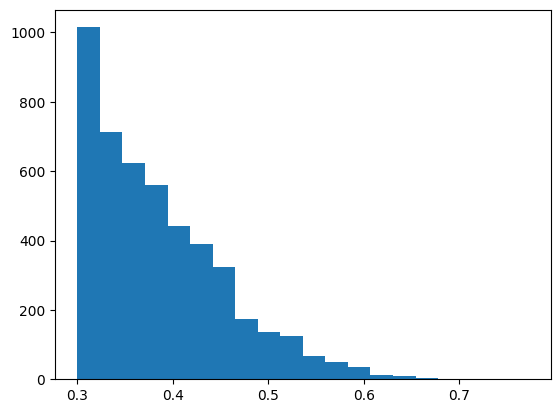

In [34]:
plt.hist(dino_results['confidences'], bins=20)

In [35]:
dino_results['class_distribution']

{'vehicle': 4343,
 'bus': 123,
 'truck': 129,
 'pedestrian': 76,
 'vehicle truck': 1,
 'bicycle': 4,
 'tricycle': 4,
 'vehicle bus': 2}

In [ ]:
llmdet_processor = AutoProcessor.from_pretrained("iSEE-Laboratory/llmdet_large")
llmdet_model = AutoModelForZeroShotObjectDetection.from_pretrained("iSEE-Laboratory/llmdet_large").to("cuda:1")

Эта модель была выбрана из-за более высоких метрик на датасетах (ODin, LVIS, COCO)

100%|██████████| 722/722 [32:59<00:00,  2.74s/it]


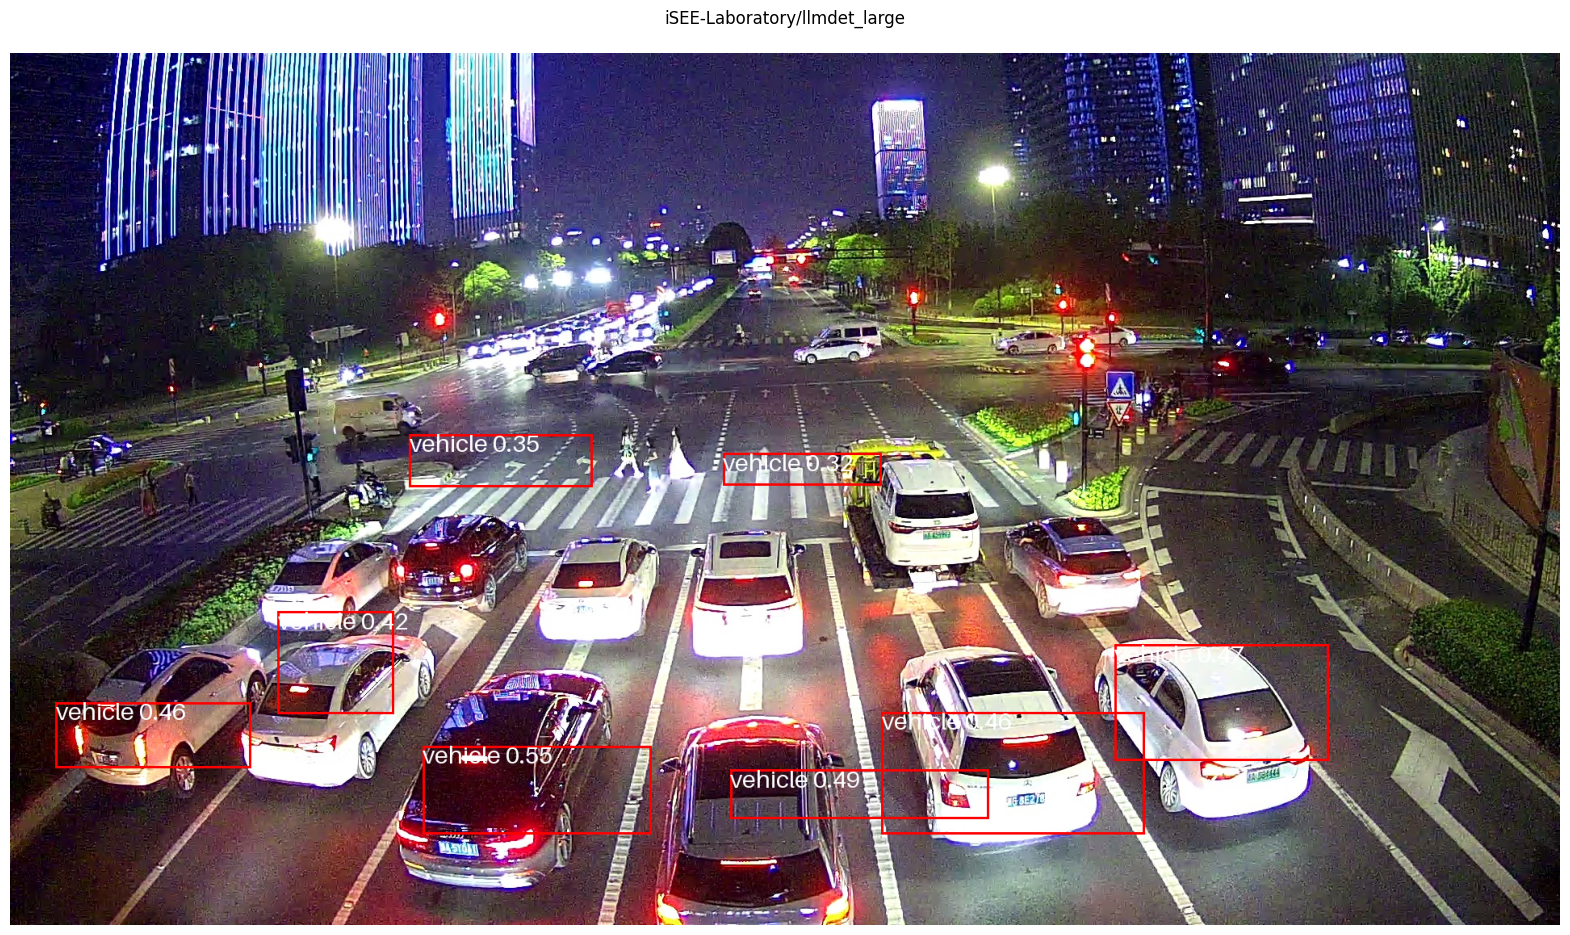

In [38]:
threshold=0.3
llmdet_results = {'confidences': [],
            'num_detections': [],
            'class_distribution': {},
            'predictions': []
        }
for img_path in tqdm(val_img):
    image = Image.open(img_path).convert("RGB")
    inputs = llmdet_processor(images=image, text=". ".join(classes) + ".", return_tensors="pt").to(llmdet_model.device)

    with torch.no_grad():
        outputs = llmdet_model(**inputs)

    detections = llmdet_processor.post_process_grounded_object_detection(
            outputs,
            input_ids=inputs.input_ids,
            threshold=threshold,
            target_sizes=[(image.height, image.width)]
        )[0]
    
    llmdet_results['confidences'].extend(detections['scores'].tolist())
    llmdet_results['num_detections'].append(len(detections['scores']))
    
    for label in detections['labels']:
        if label not in llmdet_results['class_distribution'].keys():
            llmdet_results['class_distribution'][label] = 0
        llmdet_results['class_distribution'][label] += 1
    
    llmdet_results['predictions'].append({
        'image': img_path,
        'detections': detections
    })
visualize_prediction(llmdet_results, llmdet_model.config._name_or_path)

In [39]:
metrics = calculate_ap_metrics(llmdet_results["predictions"], gt)
metrics

Подготовка данных:   0%|          | 0/722 [00:00<?, ?it/s]/tmp/ipykernel_47/3053179858.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'boxes': torch.tensor(detections['boxes'], dtype=torch.float32),
/tmp/ipykernel_47/3053179858.py:121: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'scores': torch.tensor(detections['scores'], dtype=torch.float32),
Подготовка данных: 100%|██████████| 722/722 [00:00<00:00, 8417.38it/s]


{'map': tensor(0.0047),
 'map_50': tensor(0.0189),
 'map_75': tensor(0.0004),
 'map_small': tensor(0.),
 'map_medium': tensor(1.9405e-06),
 'map_large': tensor(0.0092),
 'mar_1': tensor(0.0066),
 'mar_10': tensor(0.0071),
 'mar_100': tensor(0.0071),
 'mar_small': tensor(0.),
 'mar_medium': tensor(3.3369e-05),
 'mar_large': tensor(0.0150),
 'map_per_class': tensor([1.5184e-03, 3.6235e-02, 0.0000e+00, 3.9604e-05, 0.0000e+00, 1.4738e-04,
         0.0000e+00, 0.0000e+00]),
 'mar_100_per_class': tensor([1.9488e-03, 5.3651e-02, 0.0000e+00, 4.4444e-05, 0.0000e+00, 1.0216e-03,
         0.0000e+00, 0.0000e+00]),
 'classes': tensor([1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.int32)}

(array([908., 874., 762., 734., 684., 582., 360., 259., 164.,  63.,  14.,
          9.,   4.,   8.,  16.,  13.,  11.,   5.,   2.,   2.]),
 array([0.30005914, 0.32887092, 0.3576827 , 0.38649448, 0.41530626,
        0.44411804, 0.47292982, 0.5017416 , 0.53055338, 0.55936516,
        0.58817694, 0.61698872, 0.6458005 , 0.67461227, 0.70342405,
        0.73223583, 0.76104761, 0.78985939, 0.81867117, 0.84748295,
        0.87629473]),
 <BarContainer object of 20 artists>)

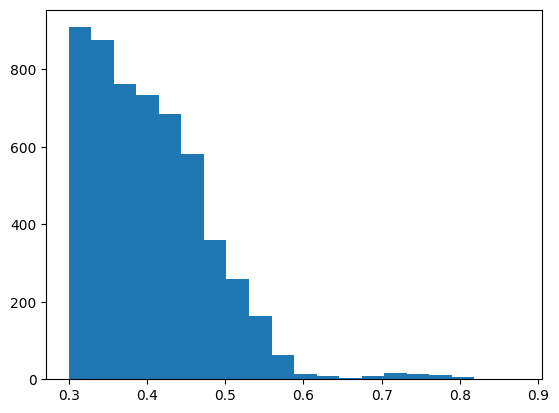

In [40]:
plt.hist(llmdet_results['confidences'], bins=20)

In [41]:
llmdet_results['class_distribution']

{'vehicle': 4439,
 'truck': 659,
 'bus': 191,
 'tricycle': 15,
 'pedestrian': 100,
 'vehicle truck': 35,
 'bicycle': 24,
 'bicycle tricycle': 5,
 '': 1,
 'bus truck': 3,
 'vehicle bus': 3}

Обе модели выдают очень низкое качество предсказаний и низкие уверенности